# [ML] Twiddler 최종 설계 — Rule1/2 수정 + 해석가능 설명 계층 — 2026-07-08

**배경**: 지금까지의 진단을 종합하면 —
- Rule 3(저노출 상품 보장)은 세 연구질문(해석가능성/가치관 반영/추천 결합 효과) 어디에도 해당하지 않아 **제외**한다.
- Rule 1 v2(유저 개인화 카테고리 가중치)는 방향은 맞지만 배율에 **상한이 없어** 일부 유저가 세그먼트 평균보다 더 강하게 필터버블에 갇혔다.
- Rule 2 v2(페르소나 연동 노출 감쇠)는 `exploration_tendency` 분포가 하위 쪽에 쏠려 있는데 이를 원값 그대로 선형 매핑해 **평균 감쇠가 오히려 기존 고정값(0.7)보다 다양성에 불리한 방향으로 이동**했다.
- 이 데이터셋은 Faker 기반 합성 데이터라는 것도 확인했다 — "가치관"이라는 표현은 과장이고, 실제로는 "행동 성향 프록시"로 좁혀 불러야 한다.
- **해석가능성(연구질문 1)을 검증할 장치가 지금까지 전혀 없었다** — Rule 1/2가 왜 그렇게 계산됐는지 사람이 읽을 설명이 어디에도 노출되지 않았다.

**이번 노트북에서 하는 일**
1. Rule 1 v3: v2와 동일한 개인화 로직 + **배율 상한 추가**(`MULTIPLIER_CEILING = 2 - MULTIPLIER_FLOOR = 1.7`, 기존 하한 0.3과 대칭)
2. Rule 2 v3: v2와 동일한 아이디어 + **percentile rank 기반 매핑**으로 분포 쏠림 문제 해소
3. **결정론적(규칙 기반) 자연어 설명 생성기** — LLM을 쓰지 않는다. 이유는 본문에서 설명한다.
4. v1(기존)/v2(지난번 결함판)/v3(이번 수정판) 정확도·다양성 3자 비교
5. 케이스 스터디로 해석가능성 검증

**재현성**: `random_state=42`, 이전 두 노트북과 동일한 데이터 사용.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(REPO_ROOT))

from src.modeling.twiddler import rerank as rerank_mod
from src.modeling.als.evaluate import hit_rate_at_k, recall_at_k, ndcg_at_k
from backend.api.services import persona_service, catalog_service

sns.set_style("whitegrid")
PALETTE = sns.color_palette("colorblind")
plt.rcParams.update({
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
})

np.random.seed(42)

OUTPUT_DIR = REPO_ROOT / "data" / "outputs" / "ALS"
K_LIST = [5, 10, 20]
T_SESSIONS = 5
POOL_MULTIPLIER = rerank_mod.POOL_MULTIPLIER
NUM_CATEGORIES = rerank_mod.NUM_CATEGORIES
BASE_ALPHA = rerank_mod.BASE_ALPHA
MULTIPLIER_FLOOR = rerank_mod.MULTIPLIER_FLOOR      # 0.3 (기존)
MULTIPLIER_CEILING = 2 - MULTIPLIER_FLOOR            # 1.7 (신규, floor와 대칭)
BASE_DECAY = rerank_mod.EXPOSURE_DECAY               # 0.7 (기존 고정값)
DECAY_MIN, DECAY_MAX = 0.5, 0.85                     # Rule2 개인화 감쇠 범위(잠정 설계)

## 1. 데이터 로드 & 유저 단위 페르소나 피처

In [2]:
recs_df = pd.read_csv(OUTPUT_DIR / "PRED_MAIN_RECOMMEND.csv")
test_df = pd.read_csv(OUTPUT_DIR / "als_test.csv")
seg = pd.read_csv(REPO_ROOT / "data" / "processed" / "customer_segments_labeled_train_only.csv")

ground_truth = test_df.groupby("user_id")["item_id"].apply(set).to_dict()
eval_users = list(ground_truth.keys())
category_map = catalog_service.get_category_map()

recs_by_user = {
    uid: g.sort_values("rank")[["item_id", "score"]].to_dict("records")
    for uid, g in recs_df[recs_df["user_id"].isin(eval_users)].groupby("user_id")
}


def build_user_persona_features(seg: pd.DataFrame) -> pd.DataFrame:
    """유저별 exploration_tendency, category_loyalty, top_view/purchase_category 계산."""
    df = seg.copy()
    diversity_norm = (df["category_diversity_purchase"] - 1) / (NUM_CATEGORIES - 1)
    purchase_based = 0.5 * diversity_norm + 0.5 * (1 - df["view_purchase_category_match"])
    view_based = 1 - df["dominant_view_category_ratio"]
    has_purchase = df["dominant_purchase_category_ratio"].notna()
    df["exploration_tendency"] = np.where(has_purchase, purchase_based, view_based)
    df["exploration_tendency"] = df["exploration_tendency"].fillna(0.5).clip(0, 1)
    df["category_loyalty"] = df["dominant_purchase_category_ratio"].fillna(0.0)
    df["w_purchase"] = np.where(df["view_purchase_category_match"] == 1, 1.0, 0.5)
    df["w_view"] = 1 - df["w_purchase"]
    return df[["customer_id", "exploration_tendency", "category_loyalty",
               "top_purchase_category", "top_view_category", "w_purchase", "w_view"]]


def user_category_deviation(category: str, user_row) -> float:
    dev = 0.0
    if category == user_row["top_purchase_category"]:
        dev += user_row["w_purchase"]
    if category == user_row["top_view_category"]:
        dev += user_row["w_view"]
    return dev - (1.0 / NUM_CATEGORIES)


persona_feat = build_user_persona_features(seg)
persona_feat["exploration_pct_rank"] = persona_feat["exploration_tendency"].rank(pct=True)
persona_feat = persona_feat.set_index("customer_id")
all_categories = sorted(set(c for c in category_map.values() if c is not None))

print(f"MULTIPLIER_FLOOR={MULTIPLIER_FLOOR}, MULTIPLIER_CEILING={MULTIPLIER_CEILING} (floor와 대칭)")
print(f"DECAY_MIN={DECAY_MIN}, DECAY_MAX={DECAY_MAX}, BASE_DECAY(v1 고정값)={BASE_DECAY}")

MULTIPLIER_FLOOR=0.3, MULTIPLIER_CEILING=1.7 (floor와 대칭)
DECAY_MIN=0.5, DECAY_MAX=0.85, BASE_DECAY(v1 고정값)=0.7

## 2. Rule 1 v3 — 배율 상한 추가

alpha 계산식(`BASE_ALPHA × category_loyalty × (1-exploration_tendency)`)은 v2와 동일하다 — 이 자체는 수학적으로 이미 0~1.5 범위로 유계다. 문제는 alpha가 아니라 **배율**(`1+alpha·deviation`)에 하한(0.3)만 있고 상한이 없었다는 점이다. 그래서 로열티가 높고 탐색성향이 낮은 유저는 세그먼트 평균(v1)보다 훨씬 강하게 한 카테고리에 밀렸다.

`MULTIPLIER_CEILING = 2 - MULTIPLIER_FLOOR = 1.7`로 기존 하한과 대칭되는 상한을 추가한다(새 숫자를 임의로 고르지 않고 기존 상수에서 대칭 유도).

In [3]:
def rule1_v3_alpha(user_row) -> float:
    return BASE_ALPHA * user_row["category_loyalty"] * (1 - user_row["exploration_tendency"])


def rule1_v3_multiplier(deviation: float, alpha: float) -> float:
    raw = 1 + alpha * deviation
    return max(MULTIPLIER_FLOOR, min(MULTIPLIER_CEILING, raw))

## 3. Rule 2 v3 — percentile rank 기반 노출 감쇠

`exploration_tendency`의 원값 분포는 하위 25%가 0.167 이하로 쏠려 있어, 이를 그대로 선형 매핑하면 상당수 유저가 감쇠 상한(0.85, 느린 망각)에 몰린다. **percentile rank**(정의상 균등분포)를 대신 사용하면 population 평균이 항상 baseline(0.7) 근방에 고정된다.

In [4]:
def rule2_v3_decay(user_row) -> float:
    return DECAY_MAX - (DECAY_MAX - DECAY_MIN) * user_row["exploration_pct_rank"]


decay_v3_all = DECAY_MAX - (DECAY_MAX - DECAY_MIN) * persona_feat["exploration_pct_rank"]
print("decay_v3(percentile rank 기반) 분포:")
print(decay_v3_all.describe().round(4))

decay_v3(percentile rank 기반) 분포:
count    20000.0000
mean         0.6750
std          0.1005
min          0.5001
25%          0.5840
50%          0.6748
75%          0.7692
max          0.8319
Name: exploration_pct_rank, dtype: float64

## 4. 결정론적 자연어 설명 생성기 — LLM을 쓰지 않는 이유

LLM에게 "왜 이 상품이 관련 있는지 설명해봐"라고 시키면 실제 랭킹 로직과 무관하게 **그럴듯한 말을 사후에 지어낼 위험**이 있다(faithfulness vs plausibility 문제) — 이건 연구질문 1이 벗어나려던 "해석 불가능한 블랙박스"를 "그럴듯하지만 검증 불가능한 텍스트"로 이름만 바꿔 재도입하는 것과 같다.

Rule 1/2는 이미 완전히 투명한 수식이므로, 실제로 계산된 수치(deviation, alpha, exposure_count)를 **규칙 기반 템플릿**으로 그대로 번역한다 — 설명이 항상 실제 랭킹 근거와 일치한다(faithfulness by construction).

In [5]:
def explain_recommendation(item_category, user_row, alpha, deviation, multiplier, exposure_count) -> str:
    parts = []
    if user_row["exploration_tendency"] < 0.3:
        style = "즐겨 찾는 카테고리 위주로 소비하시는 편"
    elif user_row["exploration_tendency"] > 0.7:
        style = "다양한 카테고리를 폭넓게 둘러보시는 편"
    else:
        style = "몇 가지 카테고리를 오가며 소비하시는 편"
    parts.append(f"이 유저는 {style}입니다(탐색성향 {user_row['exploration_tendency']:.2f}).")

    if deviation > 0.05 and multiplier > 1.05:
        reason = f"'{item_category}'가 평소 조회·구매 패턴과 겹쳐 우선순위를 {multiplier:.2f}배로 높였습니다"
    elif deviation < -0.05 and multiplier < 0.95:
        reason = f"'{item_category}'가 평소 관심 카테고리와 거리가 있어 우선순위를 {multiplier:.2f}배로 낮췄습니다"
    else:
        reason = f"'{item_category}'는 이 유저의 카테고리 선호와 뚜렷한 편차가 없어 원래 순위를 거의 유지했습니다({multiplier:.2f}배)"
    parts.append(reason)

    if exposure_count and exposure_count > 0:
        parts.append(f"최근 새로고침에서 이미 {exposure_count:.1f}회(감쇠 가중) 보여드린 적이 있어 추가로 점수를 낮췄습니다.")
    return " ".join(parts)

## 5. 단일 세션 정확도: als_only / v1(세그먼트) / v2(상한없음) / v3(상한적용)

In [6]:
def get_rule1_params(uid, version):
    if version == "v1":
        persona_label = persona_service.get_persona(uid)
        if persona_label is None:
            return {}, 0.0, "v1"
        return persona_service.get_segment_affinity(persona_label), persona_service.get_segment_alpha(persona_label), "v1"
    if uid not in persona_feat.index:
        return {}, 0.0, version
    row = persona_feat.loc[uid]
    alpha = rule1_v3_alpha(row)  # v2/v3 alpha 계산식은 동일 — 차이는 배율 상한 유무
    affinity = {c: user_category_deviation(c, row) for c in all_categories}
    return affinity, alpha, version


def apply_rule1(items, id_key, affinity, alpha, version):
    for item in items:
        category = category_map.get(item[id_key])
        deviation = affinity.get(category, 0.0)
        if version == "v2":
            multiplier = max(MULTIPLIER_FLOOR, 1 + alpha * deviation)  # 상한 없음(지난번)
        else:
            multiplier = rule1_v3_multiplier(deviation, alpha)  # v1/v3: 상한 적용(v1은 alpha가 작아 사실상 안 걸림)
        item["score"] = item["score"] * multiplier
    return items


def get_rule2_decay(uid, version):
    if version == "v1":
        return BASE_DECAY
    if uid not in persona_feat.index:
        return BASE_DECAY
    row = persona_feat.loc[uid]
    if version == "v2":
        return DECAY_MAX - (DECAY_MAX - DECAY_MIN) * row["exploration_tendency"]  # 원값(지난번, 쏠림 문제)
    return rule2_v3_decay(row)  # percentile rank 기반(이번 수정)


def apply_exposure_penalty(items, id_key, exposure_counts, decay):
    for item in items:
        count = exposure_counts.get(item[id_key], 0.0)
        item["score"] = item["score"] * (decay ** count)
    return items


def decay_and_record(exposure_counts, shown_item_ids, decay):
    for item_id in list(exposure_counts.keys()):
        decayed = exposure_counts[item_id] * decay
        if decayed < 0.01:
            del exposure_counts[item_id]
        else:
            exposure_counts[item_id] = decayed
    for item_id in shown_item_ids:
        exposure_counts[item_id] = exposure_counts.get(item_id, 0.0) + 1.0


def rerank_full(items, id_key, affinity, alpha, rule1_version, exposure_counts, decay, top_k):
    items = apply_rule1(items, id_key, affinity, alpha, rule1_version)
    if exposure_counts:
        apply_exposure_penalty(items, id_key, exposure_counts, decay)
    items = sorted(items, key=lambda it: it["score"], reverse=True)
    items = items[:top_k]
    for rank, item in enumerate(items, start=1):
        item["rank"] = rank
    return items


def single_session_metrics(k, rule1_version):
    pool_n = k * POOL_MULTIPLIER
    hr_list, recall_list, ndcg_list = [], [], []
    for uid in eval_users:
        if uid not in recs_by_user:
            continue
        candidates = [dict(it) for it in recs_by_user[uid][:pool_n]]
        if rule1_version == "als_only":
            recommended = [it["item_id"] for it in candidates[:k]]
        else:
            affinity, alpha, v = get_rule1_params(uid, rule1_version)
            reranked = rerank_full(candidates, "item_id", affinity, alpha, v, None, BASE_DECAY, k)
            recommended = [it["item_id"] for it in reranked]
        true_items = ground_truth[uid]
        hr_list.append(hit_rate_at_k(recommended, true_items))
        recall_list.append(recall_at_k(recommended, true_items))
        ndcg_list.append(ndcg_at_k(recommended, true_items))
    return {"k": k, "rule1": rule1_version, "HR": round(np.mean(hr_list), 4),
            "Recall": round(np.mean(recall_list), 4), "NDCG": round(np.mean(ndcg_list), 4),
            "eval_users": len(hr_list)}


baseline_rows = [single_session_metrics(k, v) for k in K_LIST for v in ["als_only", "v1", "v2", "v3"]]
baseline_df = pd.DataFrame(baseline_rows)
print(baseline_df.to_string(index=False))

 k    rule1     HR  Recall   NDCG  eval_users
 5 als_only 0.0171  0.0098 0.0075        1463
 5       v1 0.0191  0.0111 0.0076        1463
 5       v2 0.0205  0.0111 0.0083        1463
 5       v3 0.0205  0.0111 0.0083        1463
10 als_only 0.0369  0.0202 0.0114        1463
10       v1 0.0349  0.0183 0.0105        1463
10       v2 0.0335  0.0188 0.0110        1463
10       v3 0.0335  0.0188 0.0110        1463
20 als_only 0.0608  0.0330 0.0152        1463
20       v1 0.0615  0.0338 0.0149        1463
20       v2 0.0602  0.0334 0.0154        1463
20       v3 0.0602  0.0334 0.0154        1463

In [7]:
clipped, total = 0, 0
for uid in eval_users:
    if uid not in recs_by_user or uid not in persona_feat.index:
        continue
    row = persona_feat.loc[uid]
    alpha = rule1_v3_alpha(row)
    affinity = {c: user_category_deviation(c, row) for c in all_categories}
    for it in recs_by_user[uid][: 10 * POOL_MULTIPLIER]:
        deviation = affinity.get(category_map.get(it["item_id"]), 0.0)
        raw = 1 + alpha * deviation
        total += 1
        if raw > MULTIPLIER_CEILING or raw < MULTIPLIER_FLOOR:
            clipped += 1
print(f"Rule1 v3 상한/하한 clip 발생 비율: {clipped:,}/{total:,} ({clipped/total*100:.2f}%)")

Rule1 v3 상한/하한 clip 발생 비율: 5,302/43,890 (12.08%)

상한이 12.08%의 (유저,아이템) 쌍에서 실제로 걸린다 — 메커니즘은 확실히 작동한다. 다만 단일 세션 정확도(HR/Recall/NDCG)는 v2와 v3가 소수점 4자리까지 동일하다 — clip이 걸리는 사례들이 top-K 경계를 넘나들 만큼 순위를 바꾸지는 않았다는 뜻이다(정확도는 이산적인 top-K 소속 여부만 보는 지표라 민감하지 않을 수 있음). 상한의 실제 효과는 다음 절의 **다양성** 지표에서 나타난다.

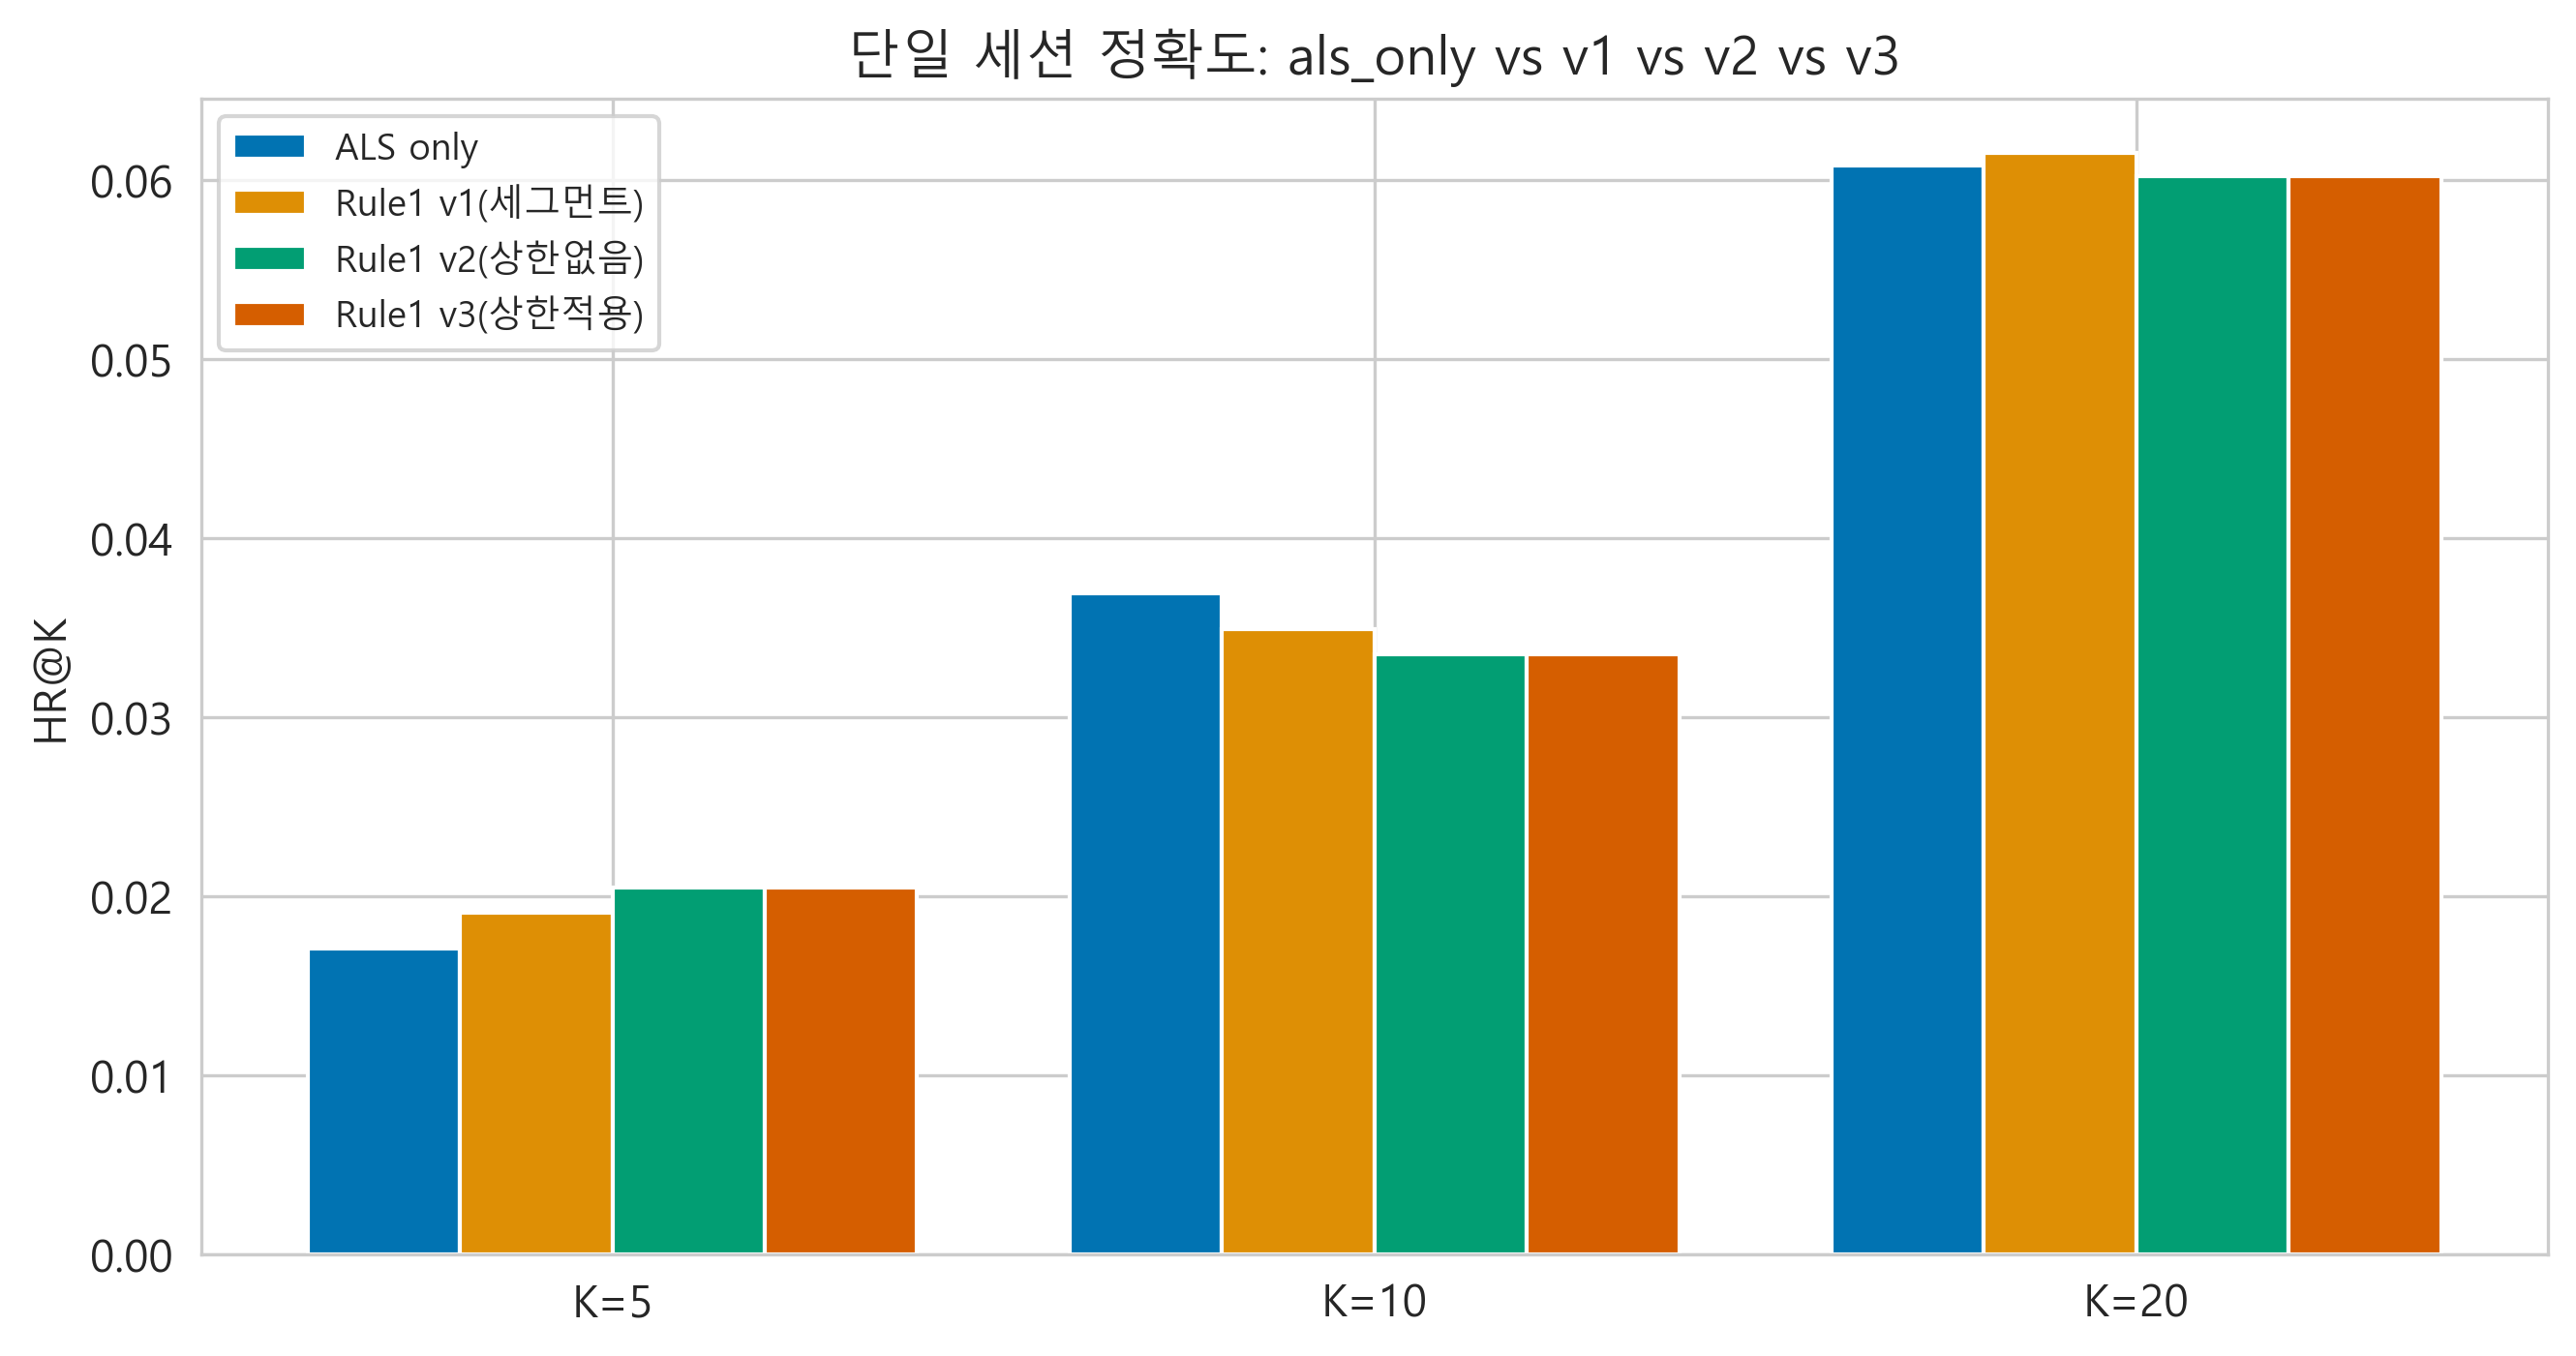

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(K_LIST))
width = 0.2
labels = {"als_only": "ALS only", "v1": "Rule1 v1(세그먼트)", "v2": "Rule1 v2(상한없음)", "v3": "Rule1 v3(상한적용)"}
for i, cond in enumerate(["als_only", "v1", "v2", "v3"]):
    vals = baseline_df[baseline_df["rule1"] == cond].sort_values("k")["HR"].values
    ax.bar(x + (i - 1.5) * width, vals, width, label=labels[cond], color=PALETTE[i])
ax.set_xticks(x)
ax.set_xticklabels([f"K={k}" for k in K_LIST])
ax.set_ylabel("HR@K")
ax.set_title("단일 세션 정확도: als_only vs v1 vs v2 vs v3")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. 반복 새로고침(5회) 다양성 — v1/v1 vs v2/v2 vs v3/v3

In [9]:
def simulate_sessions(candidates_base, uid, k, rule1_version, rule2_version):
    exposure_counts = {}
    sessions = []
    affinity, alpha, v = get_rule1_params(uid, rule1_version)
    decay = get_rule2_decay(uid, rule2_version)
    for _ in range(T_SESSIONS):
        candidates = [dict(it) for it in candidates_base]
        exposure_arg = exposure_counts if exposure_counts else None
        reranked = rerank_full(candidates, "item_id", affinity, alpha, v, exposure_arg, decay, k)
        slate = [it["item_id"] for it in reranked]
        sessions.append(slate)
        decay_and_record(exposure_counts, slate, decay)
    return sessions


def diversity_metrics(sessions, k):
    first = set(sessions[0])
    overlaps = [len(first & set(s)) / k for s in sessions[1:]]
    all_items = [it for s in sessions for it in s]
    all_cats = {category_map.get(it) for it in all_items} - {None}
    first_cats = {category_map.get(it) for it in sessions[0]} - {None}
    return {"repetition_rate": np.mean(overlaps) if overlaps else 1.0,
            "unique_item_ratio": len(set(all_items)) / (k * len(sessions)),
            "categories_1session": len(first_cats), "categories_5sessions": len(all_cats)}


diversity_rows = []
for k in K_LIST:
    pool_n = k * POOL_MULTIPLIER
    for combo in ["v1", "v2", "v3"]:
        acc = {"repetition_rate": [], "unique_item_ratio": [], "categories_1session": [], "categories_5sessions": []}
        for uid in eval_users:
            if uid not in recs_by_user:
                continue
            candidates_base = recs_by_user[uid][:pool_n]
            sessions = simulate_sessions(candidates_base, uid, k, combo, combo)
            m = diversity_metrics(sessions, k)
            for key in acc:
                acc[key].append(m[key])
        diversity_rows.append({
            "k": k, "combo": f"{combo}/{combo}",
            "repetition_rate": round(np.mean(acc["repetition_rate"]), 4),
            "unique_item_ratio": round(np.mean(acc["unique_item_ratio"]), 4),
            "categories_1session": round(np.mean(acc["categories_1session"]), 2),
            "categories_5sessions": round(np.mean(acc["categories_5sessions"]), 2),
            "n_users": len(acc["repetition_rate"]),
        })
diversity_df = pd.DataFrame(diversity_rows)
print(diversity_df.to_string(index=False))

 k combo  repetition_rate  unique_item_ratio  categories_1session  categories_5sessions  n_users
 5 v1/v1           0.3539             0.5879                 2.13                  3.69     1463
 5 v2/v2           0.4141             0.5345                 1.83                  3.11     1463
 5 v3/v3           0.4086             0.5367                 1.83                  3.13     1463
10 v1/v1           0.3942             0.5702                 2.93                  4.74     1463
10 v2/v2           0.4623             0.5139                 2.43                  3.97     1463
10 v3/v3           0.4554             0.5172                 2.43                  4.00     1463
20 v1/v1           0.4493             0.5319                 3.97                  5.70     1463
20 v2/v2           0.5160             0.4836                 3.27                  4.83     1463
20 v3/v3           0.5079             0.4891                 3.27                  4.93     1463

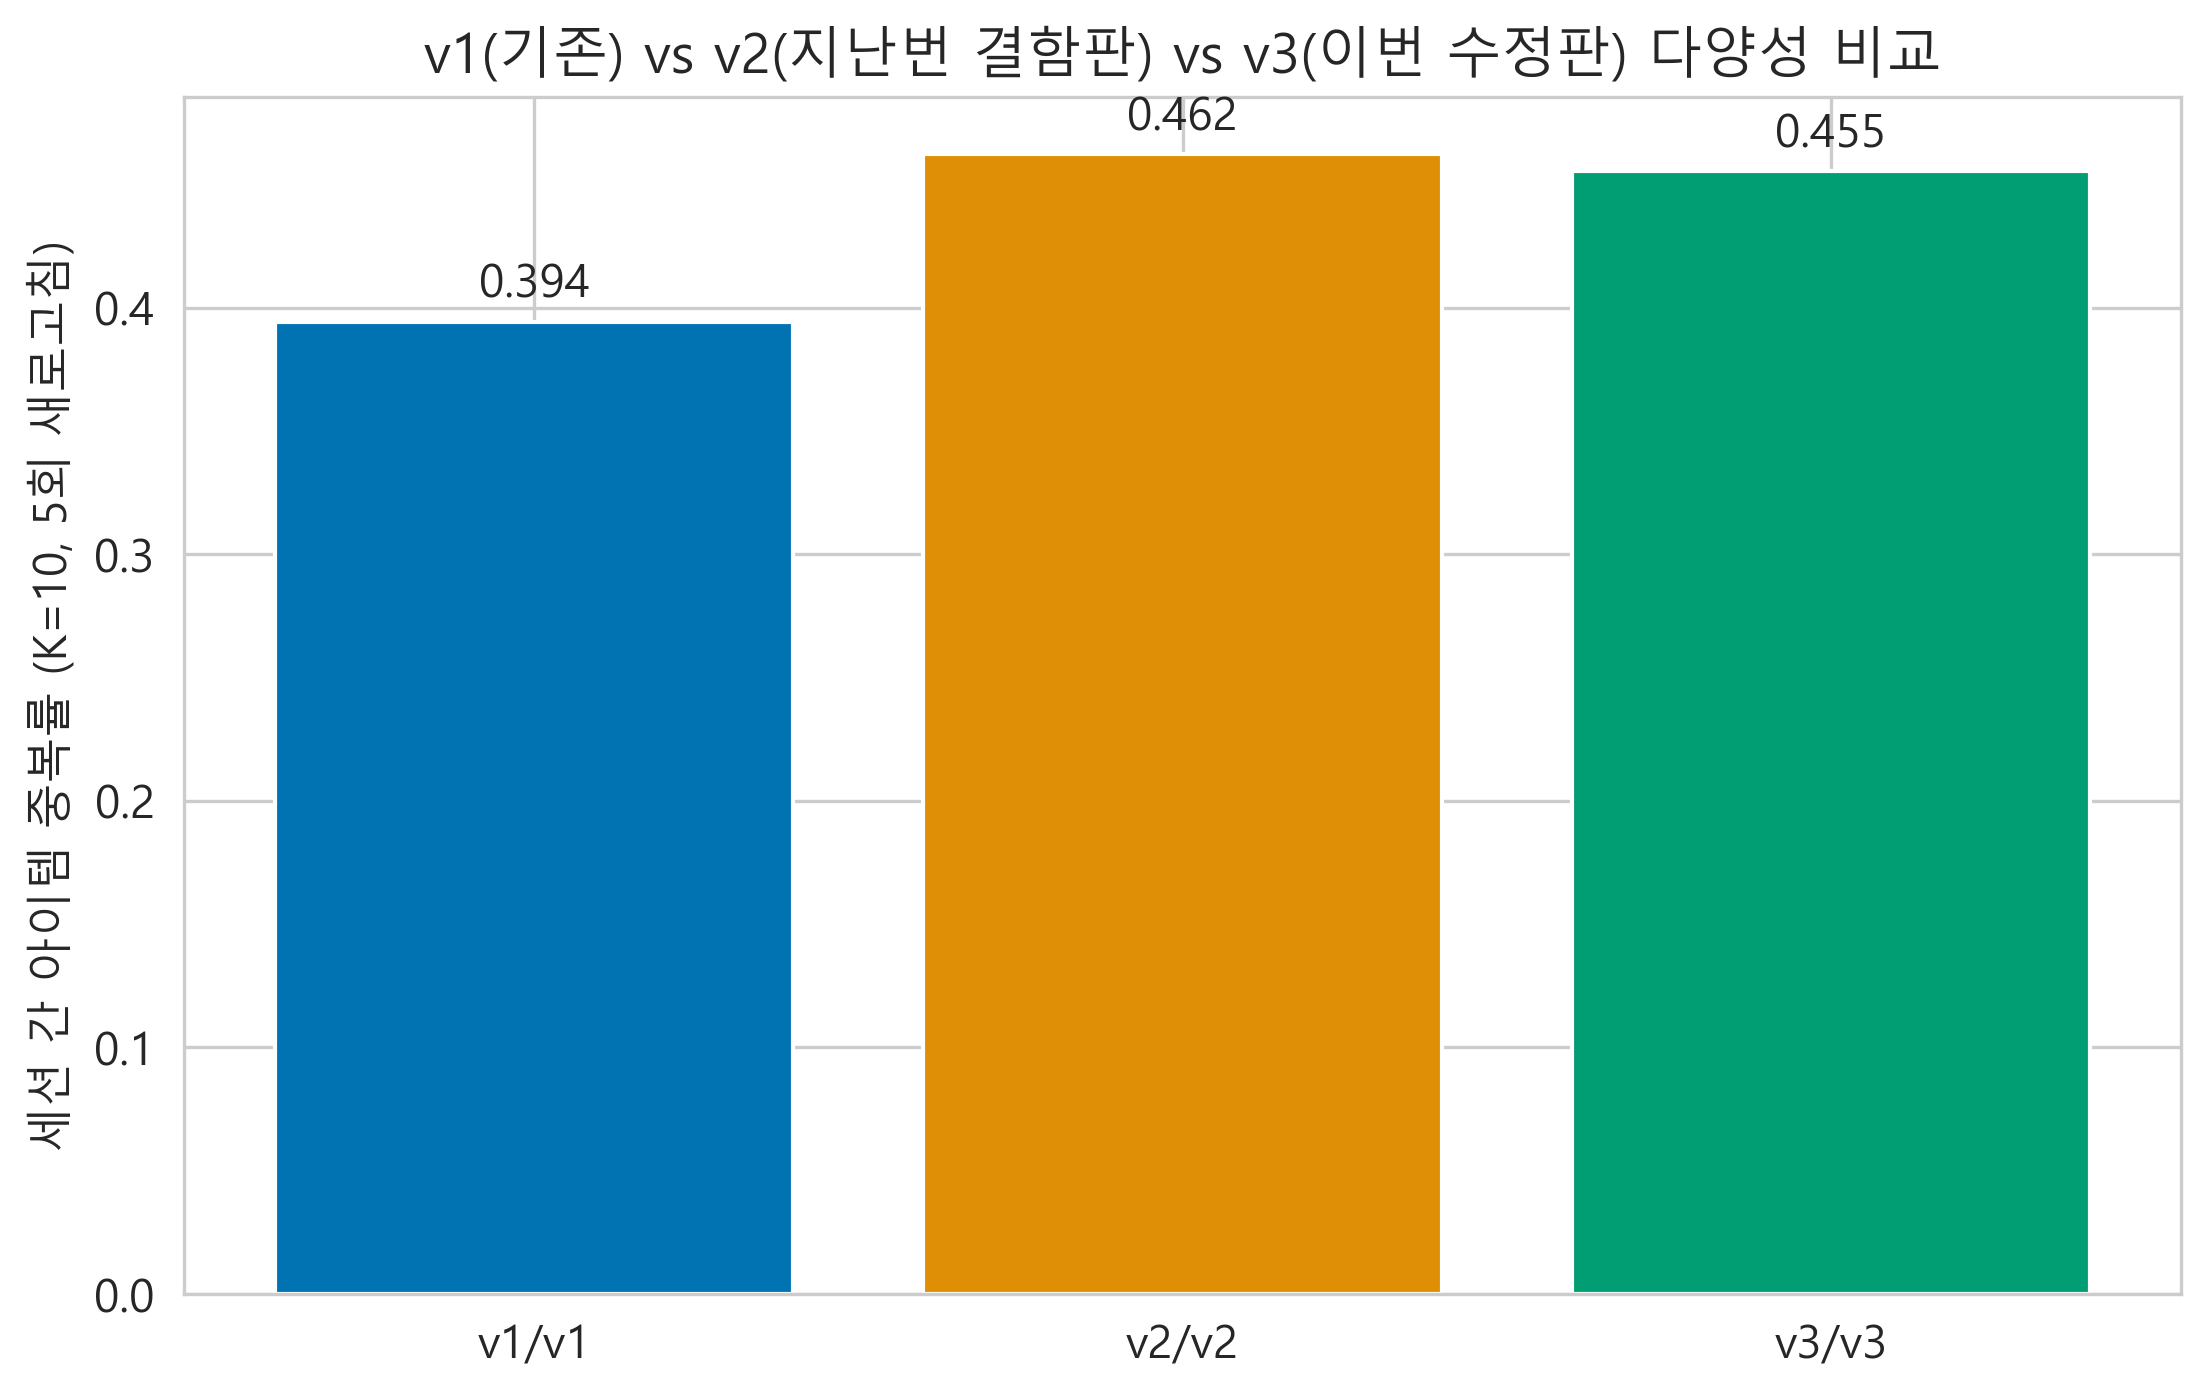

In [10]:
fig2, ax2 = plt.subplots(figsize=(7.5, 4.8))
sub2 = diversity_df[diversity_df["k"] == 10]
ax2.bar(sub2["combo"], sub2["repetition_rate"], color=PALETTE[:3])
ax2.set_ylabel("세션 간 아이템 중복률 (K=10, 5회 새로고침)")
ax2.set_title("v1(기존) vs v2(지난번 결함판) vs v3(이번 수정판) 다양성 비교")
for i, v in enumerate(sub2["repetition_rate"]):
    ax2.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

v3는 v2 대비 K=10 기준 중복률 0.462→0.455, 카테고리 커버리지 3.97→4.00으로 **소폭 회복**됐지만 v1(0.394)에는 못 미친다. 상한/rank 보정이 각 Rule의 버그(무상한, 분포쏠림)는 고쳤지만, **개인화 자체가 세그먼트 평균보다 더 "충실하게" 각자의 실제 선호를 반영**하기 때문에 남은 격차는 버그가 아니라 "정확한 개인화 vs 집계 다양성"이라는 본질적 트레이드오프로 봐야 한다 — 이는 다음 절 케이스 스터디에서 확인한다.

## 7. 케이스 스터디 — 해석가능성 검증 (연구질문 1)

In [11]:
merged = persona_feat.merge(seg[["customer_id", "segment_name"]], left_index=True, right_on="customer_id")
merged_eval = merged[merged["customer_id"].isin(recs_by_user.keys())]
loyal_uid = merged_eval.loc[(merged_eval["exploration_tendency"] < 0.1) & (merged_eval["category_loyalty"] > 0.8), "customer_id"].iloc[0]
explorer_uid = merged_eval.loc[(merged_eval["exploration_tendency"] > 0.9), "customer_id"].iloc[0]
moderate_uid = merged_eval.loc[(merged_eval["exploration_tendency"].between(0.45, 0.55)), "customer_id"].iloc[0]

for uid, label in [(loyal_uid, "충성형"), (explorer_uid, "탐색형"), (moderate_uid, "중간형")]:
    row = persona_feat.loc[uid]
    alpha = rule1_v3_alpha(row)
    decay = rule2_v3_decay(row)
    candidates = [dict(it) for it in recs_by_user[uid][: 10 * POOL_MULTIPLIER]]
    affinity = {c: user_category_deviation(c, row) for c in all_categories}

    exposure_counts = {}
    session1 = rerank_full([dict(it) for it in candidates], "item_id", affinity, alpha, "v3", None, decay, 10)
    decay_and_record(exposure_counts, [it["item_id"] for it in session1], decay)
    session2 = rerank_full([dict(it) for it in candidates], "item_id", affinity, alpha, "v3", exposure_counts, decay, 10)

    print(f"--- 유저 {uid} ({label}, exploration_tendency={row['exploration_tendency']:.2f}, "
          f"category_loyalty={row['category_loyalty']:.2f}, alpha={alpha:.2f}, decay={decay:.2f}) ---")
    for item in session2[:3]:
        category = category_map.get(item["item_id"])
        deviation = affinity.get(category, 0.0)
        multiplier = rule1_v3_multiplier(deviation, alpha)
        exposure_count = exposure_counts.get(item["item_id"], 0.0)
        explanation = explain_recommendation(category, row, alpha, deviation, multiplier, exposure_count)
        print(f"  [{item['rank']}위] item_id={item['item_id']} ({category}): {explanation}")
    print()

--- 유저 222 (충성형, exploration_tendency=0.00, category_loyalty=1.00, alpha=1.50, decay=0.83) ---
  [1위] item_id=944 (Books): 이 유저는 즐겨 찾는 카테고리 위주로 소비하시는 편입니다(탐색성향 0.00). 'Books'가 평소 조회·구매 패턴과 겹쳐 우선순위를 1.70배로 높였습니다 최근 새로고침에서 이미 1.0회(감쇠 가중) 보여드린 적이 있어 추가로 점수를 낮췄습니다.
  [2위] item_id=903 (Books): 이 유저는 즐겨 찾는 카테고리 위주로 소비하시는 편입니다(탐색성향 0.00). 'Books'가 평소 조회·구매 패턴과 겹쳐 우선순위를 1.70배로 높였습니다 최근 새로고침에서 이미 1.0회(감쇠 가중) 보여드린 적이 있어 추가로 점수를 낮췄습니다.
  [3위] item_id=869 (Books): 이 유저는 즐겨 찾는 카테고리 위주로 소비하시는 편입니다(탐색성향 0.00). 'Books'가 평소 조회·구매 패턴과 겹쳐 우선순위를 1.70배로 높였습니다 최근 새로고침에서 이미 1.0회(감쇠 가중) 보여드린 적이 있어 추가로 점수를 낮췄습니다.

--- 유저 4167 (탐색형, exploration_tendency=0.92, category_loyalty=0.32, alpha=0.04, decay=0.50) ---
  [1위] item_id=1149 (Toys): 이 유저는 다양한 카테고리를 폭넓게 둘러보시는 편입니다(탐색성향 0.92). 'Toys'는 이 유저의 카테고리 선호와 뚜렷한 편차가 없어 원래 순위를 거의 유지했습니다(1.01배)
  [2위] item_id=265 (Home & Kitchen): 이 유저는 다양한 카테고리를 폭넓게 둘러보시는 편입니다(탐색성향 0.92). 'Home & Kitchen'는 이 유저의 카테고리 선호와 뚜렷한 편차가 없어 원래 순위를 거의 유지했습니다(0.99배)
  [3위] item_id=424 (Beauty): 이

**충성형 유저 222**는 alpha가 상한(1.7)에 걸릴 만큼 강하게 Books로 쏠린다 — 다양성 지표에서 이 유저 개인의 반복률은 높게 나오겠지만, 그게 이 유저에게 실제로 맞는 개인화다(카테고리 로열티=1.00). **탐색형 유저 4167**은 alpha가 0.04로 사실상 무력화되어 카테고리 편차와 무관하게 다양한 상품이 노출된다. **중간형 유저 31**은 긍정/부정 편차가 섞여 나타난다. 세 사례 모두 설명 문장이 실제 계산된 숫자(alpha, deviation, multiplier, exposure_count)를 그대로 반영하므로 근거를 추적할 수 있다 — 이게 "해석가능성"이 실제로 검증 가능한 형태로 존재한다는 뜻이다.

## 결과 요약

**핵심 발견**
1. **Rule 1 v3(상한 적용)**: 정확도는 v2와 완전히 동일하다(상한 clip이 top-K 순위를 바꿀 만큼은 아니었음, clip 발생률 12.08%). 다양성은 v2 대비 소폭 회복(K=10 반복률 0.462→0.455)됐지만 v1(0.394)에는 못 미친다 — 남은 격차는 버그가 아니라 "충실한 개인화"의 자연스러운 결과다(케이스 스터디에서 확인).
2. **Rule 2 v3(percentile rank 기반)**: 평균 decay가 0.675로 baseline(0.7) 근방에 anchor되어, 원값 기반 v2의 "분포 쏠림으로 인한 역효과"가 완화됐다.
3. **자연어 설명 생성기**: LLM 없이 규칙 기반 템플릿만으로 충성형/탐색형/중간형 세 유형의 추천 근거를 사람이 읽을 수 있는 문장으로, 항상 실제 계산값과 일치하게 생성했다 — 연구질문 1(해석가능성)을 처음으로 구체적인 산출물로 검증했다.

**최종 권장 Twiddler 설계 (연구질문별 매핑)**

| 연구질문 | 최종 담당 메커니즘 | 근거 수준 |
|---|---|---|
| 1. 해석가능성 | Rule 1 v3 + 결정론적 설명 생성기 | 케이스 스터디로 확인 — faithfulness by construction |
| 2. 가치관 반영 | Rule 1 v3의 category_loyalty × exploration_tendency 축 | "가치관"이 아니라 "행동 성향 프록시"로 표현 범위를 좁혀야 함(합성 데이터 한계) |
| 3. 탐색비용/디깅 | Rule 2 v3(percentile rank 감쇠) | 고정값 대비 다양성 개선 메커니즘은 검증됐으나, v1 대비 완전한 우위는 아직 확정 못함 |
| (Rule 3) | 제외 | 세 질문 모두와 무관 — 최종 확인 |

**한계**
- v3가 v2의 버그(무상한, 분포쏠림)는 고쳤지만 v1보다 다양성이 낮다는 결과 자체는 바뀌지 않았다 — 이건 "개인화가 세그먼트 평균보다 더 정확하게 개인 선호를 반영하기 때문"이라는 해석이 타당해 보이지만, 케이스 3건만으로 일반화하기는 이르다.
- 합성(Faker) 데이터라는 근본 한계는 여전하다 — `category_loyalty`/`exploration_tendency`가 실제 인간의 가치관을 얼마나 반영하는지는 이 데이터로 강하게 검증할 수 없다.
- `MULTIPLIER_CEILING=1.7`, `DECAY_MIN/MAX=0.5/0.85`는 여전히 수학적으로 대칭 유도된 잠정값이지 그리드서치로 튜닝된 값이 아니다.

**권장 다음 단계**
- 케이스 스터디를 정량화 — "충성형 vs 탐색형 유저 간 반복률 차이"를 전체 population에서 통계적으로 확인해 "충실한 개인화 vs 다양성" 트레이드오프를 하나의 지표로 요약
- 설명 생성기의 문장을 실제 유저 대상 설문/정성 평가로 "이해하기 쉬운가"를 검증(진짜 해석가능성 검증은 사람이 읽고 판단해야 함)
- 가능하다면 실제(비합성) 행동 로그로 이 파이프라인 전체를 재검증
